## 第2章：文本数据处理

### 2.1 词嵌入

包括大语言模型在内的深度神经网络通常不能直接处理原始文本，因为文本是离散符号，无法直接用于神经网络训练所需的连续数学运算。为了解决这个问题，需要把词或文本转换成由连续数值组成的向量，这个把数据变成向量的过程就叫做**嵌入（embedding）**。嵌入可以通过模型中的特定神经网络层来完成，也可以借助另一个预训练的神经网络模型来完成

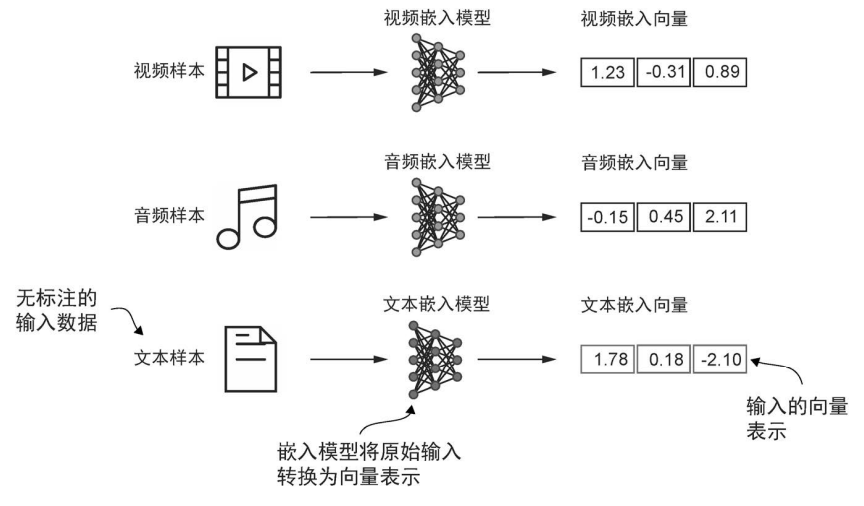

### 2.2 文本分词

在进行嵌入之前，模型通常会先把原始文本变成可计算的输入，而分词就是第一步。分词的结果是一串更小的符号单元，**token**，它们可能是词、子词、标点，甚至是空格等。接下来，模型会把这些token映射成数字编号，再进一步转换成向量表示，这样就能在神经网络里进行后续的训练或推理计算。

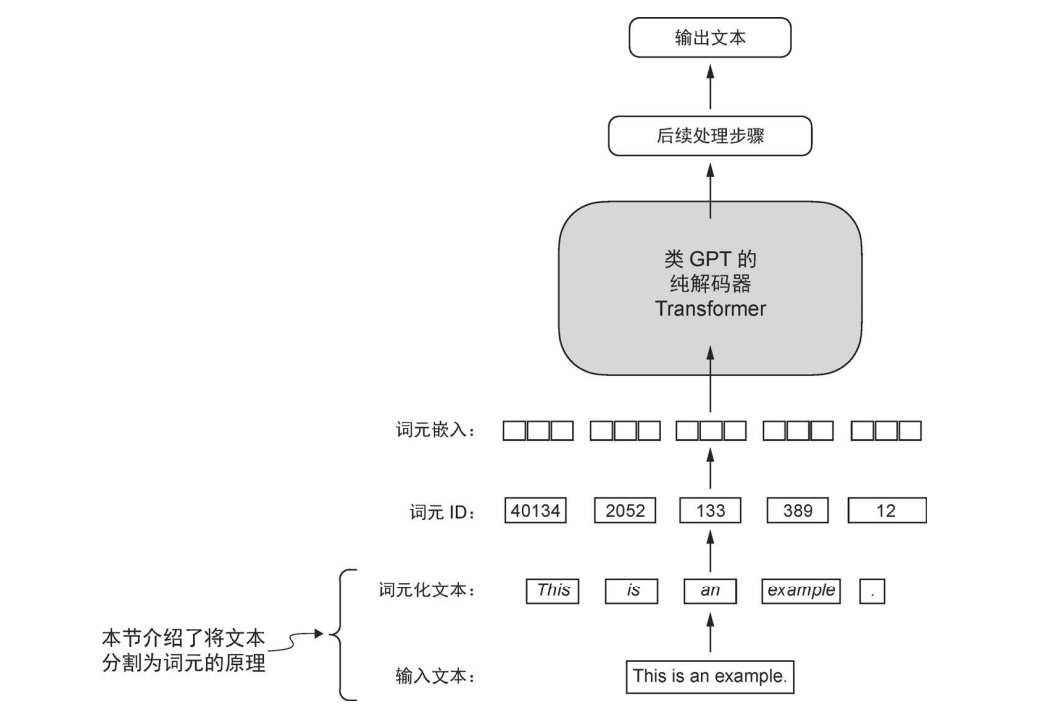

首先，我们需要加载要处理的原始文本数据。这里可以使用Edith Wharton的短篇小说《The Verdict》， https://en.wikisource.org/wiki/The_Verdict 。

In [2]:
import os
import urllib.request

if not os.path.exists("the-verdict.txt"):
# 如果本地没有这个文本文件，就执行下载

    url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/refs/heads/main/ch02/01_main-chapter-code/the-verdict.txt"
    # 文本文件的网络地址

    urllib.request.urlretrieve(url, "the-verdict.txt")
    # 下载并保存为本地文件 the-verdict.txt

In [3]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
# 以 UTF-8 编码打开文本文件（只读）

    raw_text = f.read()
    # 读取文件全部内容到 raw_text

In [6]:
# raw_text # 可以自行查看原文本内容

In [7]:
len(raw_text) # 文本长度

20479

我们的目标是把这段文本先**分词（tokenize）**，再进行**嵌入（embedding）**，从而让大语言模型能够使用它。为了更容易理解，我们先用一段简单的示例文本来开发一个基础版的分词器，之后再把同样的方法应用到上面的长文本中。接下来我们会用一个**正则表达式**按空白字符（例如空格、换行、制表符）来进行切分。

In [8]:
import re

text = "Hello, world. This, is a test."
result = re.split(r'(\s)',text)

print(result)

['Hello,', ' ', 'world.', ' ', 'This,', ' ', 'is', ' ', 'a', ' ', 'test.']


我们不仅希望按空白字符来切分文本，也希望把逗号和句号等标点符号一起作为切分边界，所以需要对正则表达式做相应修改，让它同时支持按空白和这些标点进行分割。

In [6]:
result = re.split(r'([,.]|\s)',text)
print(result)

['Hello', ',', '', ' ', 'world', '.', '', ' ', 'This', ',', '', ' ', 'is', ' ', 'a', ' ', 'test', '.', '']


我们可以看到，这样的切分结果里会出现一些空字符串，因此需要把这些空字符串过滤掉，只保留真正有内容的token。

In [10]:
result = [item for item in result if item.strip()]
# 过滤掉空字符串或只包含空白的分词结果

print(result)

['Hello,', 'world.', 'This,', 'is', 'a', 'test.']


我们还可以进一步处理更多类型的标点符号，比如句号、问号以及其他常见标点，这样分词结果会更完整、更贴近真实文本的情况。

In [15]:
text = "Hello, world. Is this-- a test?"

result = re.split(r'([,.:;?_!"()\']|--|\s)',raw_text)
# 用正则把标点、双连字符和空白都作为切分边界，同时保留这些符号本身

result = result = [item for item in result if item.strip()]
# 去掉切分后产生的空字符串

preprocessed = result
# 将清理后的 token 列表保存为预处理结果

In [9]:
len(preprocessed) 

4690

### 2.3 词元id

接下来，我们会把文本的token转换成对应的数字编号（token ID），这样后续就可以通过嵌入层（embedding layer）对这些编号进行处理并得到向量表示。

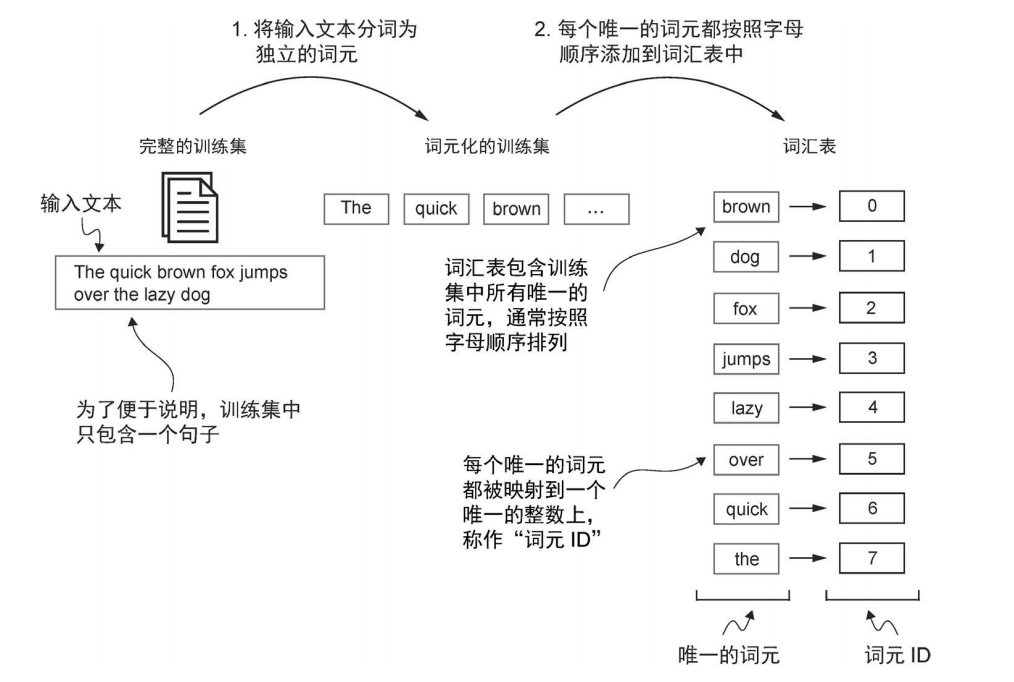

基于上面分词得到的token，我们就可以构建一个**词表（vocabulary）**，它包含文本中出现过的所有不重复的token。

In [17]:
all_words = sorted(set(preprocessed))

In [18]:
vocab_size = len(all_words)
print(vocab_size)

1130


In [19]:
vocab = {token:integer for integer, token in enumerate(all_words)}
# 用 enumerate 给每个唯一 token 分配一个编号，构建 token→ID 的词表字典

In [13]:
#vocab 

比如说我们可以看看"Jack"这个单词的token id是多少。

In [20]:
vocab["Jack"]

57

In [21]:
int_to_str = {i:s for s,i in vocab.items()}
# 把 vocab 反转，得到 ID→token 的映射字典，方便从编号还原成文本

int_to_str[57]

'Jack'

接下来，我们把前面的步骤整合起来，封装成一个**分词器（tokenizer）**类，方便后续重复使用。

In [41]:
class SimpleTokenizerV1:
    def __init__(self, vocab):
        self.str_to_int = vocab
        # 保存 token→ID 的映射，并构建反向的 ID→token 映射，方便解码
        self.int_to_str = {i:s for s,i in vocab.items()}
        # 反向词表：用于把 ID 还原回 token
        
    def encode(self,text):
        preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)',text)
        # 按标点、双连字符和空白切分，同时保留这些符号

        preprocessed = [
              item.strip() for item in preprocessed if item.strip()
        ]
        # 去掉空字符串，并做一次简单清理

        ids = [self.str_to_int[s] for s in preprocessed]
        # 把 token 序列映射成 ID 序列
        return ids

    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        # 把 ID 序列还原成 token，并用空格拼接成字符串

        text = re.sub(r'\s+([,.:;?!"()\'])',r'\1',text)
        # 去掉标点前多余的空格，让文本更自然
        return text

In [42]:
tokenizer = SimpleTokenizerV1(vocab)

我们可以用分词器把文本编码成一串整数，也就是把文本分词并映射为对应的token ID。接下来，这些整数就可以在后续步骤中通过嵌入层转换成向量表示，作为大语言模型的输入。

In [43]:
text =  """ "I like to fancy that Stroud himself would have given it to me, if he'd been able to say what he thought that day." """

In [44]:
ids = tokenizer.encode(text) #编码文本

In [45]:
print(ids)

[1, 53, 628, 1016, 429, 987, 89, 547, 1120, 530, 491, 585, 1016, 663, 5, 566, 533, 2, 310, 208, 117, 1016, 856, 1089, 533, 1003, 987, 315, 7, 1]


In [46]:
tokenizer.decode(ids) # 解码

'" I like to fancy that Stroud himself would have given it to me, if he\' d been able to say what he thought that day."'

In [47]:
tokenizer.decode(tokenizer.encode(text))

'" I like to fancy that Stroud himself would have given it to me, if he\' d been able to say what he thought that day."'

### 2.4 特殊词元

在实际使用中，给分词器加入一些特殊token会很有用，比如用来表示词表之外的**未知词（unknown）**，以及用来标记一段**文本结束的位置（end of text）**，这样模型在遇到新词或需要区分文本边界时会更方便处理。

In [54]:
tokenizer = SimpleTokenizerV1(vocab)

text = "Hello, do you like tea. Is this-- a test?"

tokenizer.encode(text)

KeyError: 'Hello'

上面的代码之所以会报错，是因为词表里并不包含“Hello”这个词。为了解决这种情况，我们可以在词表中加入像`<|unk|>`这样的特殊token，用来表示词表之外的未知词。

既然我们已经在扩展词表了，也可以顺便再加入一个`<|endoftext|>`token，它在GPT-2训练中用来标记一段文本的结束，同时也常用于拼接多段文本时作为分隔符，例如当训练数据由多篇文章、多本书等组成时，会在不同文本之间插入这个标记。

In [55]:
all_tokens = sorted(list(set(preprocessed)))
# 对预处理后的 token 去重并排序，得到词表的基础 token 集合

all_tokens.extend(["<|endoftext|>","<|unk|>"])
# 添加特殊 token：文本结束标记和未知词标记

vocab = {token:integer for integer,token in enumerate(all_tokens)}
# 为每个 token 分配唯一的整数 ID，构建 token→ID 的词表映射

In [56]:
len(vocab.items())

1132

我们可以遍历词表字典最后 5 个条目，看看是否添加进去了。

In [57]:
for i, item in enumerate(list(vocab.items())[-5:]):
    print(item)

('younger', 1127)
('your', 1128)
('yourself', 1129)
('<|endoftext|>', 1130)
('<|unk|>', 1131)


可以看到，`<|unk|>`已经被我们添加到词典里。

In [58]:
for i, item in enumerate(list(vocab.items())[:5]):
    print(item)

('!', 0)
('"', 1)
("'", 2)
('(', 3)
(')', 4)


我们可以调整上一节所编写的分词器，让它能够识别并正确使用新的`<|unk|>`标记，也就是当遇到词表中不存在的token时，自动用`<|unk|>`来替代。

In [59]:
class SimpleTokenizerV2:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = {i:s for s,i in vocab.items()}

    def encode(self,text):
        preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)',text)

        preprocessed = [
              item.strip() for item in preprocessed if item.strip()
        ]
        preprocessed = [item if item in self.str_to_int
              else "<|unk|>" for item in preprocessed]
        # 遇到不在词表中的 token，用 <|unk|> 代替

        ids = [self.str_to_int[s] for s in preprocessed]
        return ids

    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])

        text = re.sub(r'\s+([,.:;?!"()\'])',r'\1',text)
        return text

In [60]:
tokenizer = SimpleTokenizerV2(vocab)

我们重新检验一下这句文本内容。

In [62]:
text = "Hello,do you like tea. is this-- a test?"

In [63]:
tokenizer.encode(text)

[1131, 5, 355, 1126, 628, 975, 7, 584, 999, 6, 115, 1131, 10]

In [64]:
tokenizer.decode(tokenizer.encode(text))

'<|unk|>, do you like tea. is this -- a <|unk|>?'

### 2.5 BPE分词

GPT-2使用 **Byte Pair Encoding（BPE，字节对编码）** 作为它的分词方法，这种方法允许模型把不在预定义词表里的单词进一步拆成更小的子词单元，甚至拆到单个字符，从而能够更好地处理“词表外词”。

比如如果GPT-2的词表里没有“unfamiliarword”这个词，它可能会把它切分成["unfam", "iliar", "word"]，具体怎么拆取决于BPE在训练时学到的合并规则。

In [65]:
# pip install tiktoken # 如果没有安装tiktoken可选择下载

In [67]:
import tiktoken

In [68]:
pip install tiktoken

Note: you may need to restart the kernel to use updated packages.


In [69]:
tiktoken.__version__

'0.12.0'

In [70]:
tokenizer = tiktoken.get_encoding("gpt2")
# 加载 tiktoken 内置的 GPT-2 分词器（BPE 规则与词表），用于把文本编码成 token/ID

In [71]:
tokenizer.encode("Hello world")

[15496, 995]

In [37]:
tokenizer.decode(tokenizer.encode("Hello world"))

'Hello world'

BPE分词器会把词表中没有的未知词拆分成更小的子词单元，必要时甚至会拆到单个字符，从而让模型仍然能够对这些词进行编码和处理。

In [38]:
text = ( 
 "Hello, do you like tea? <|endoftext|> In the sunlit terraces" 
 "of someunknownPlace." 
)

tokenizer.encode(text,allowed_special={"<|endoftext|>"})

[15496,
 11,
 466,
 345,
 588,
 8887,
 30,
 220,
 50256,
 554,
 262,
 4252,
 18250,
 8812,
 2114,
 1659,
 617,
 34680,
 27271,
 13]

### 2.6 使用滑动窗口进行数据采样

在训练大语言模型时，模型通常按顺序一次生成一个词（更准确地说是一个token），因此我们需要把训练数据整理成“输入序列→预测下一个词”的形式，也就是让序列中的下一个词作为模型要预测的目标。

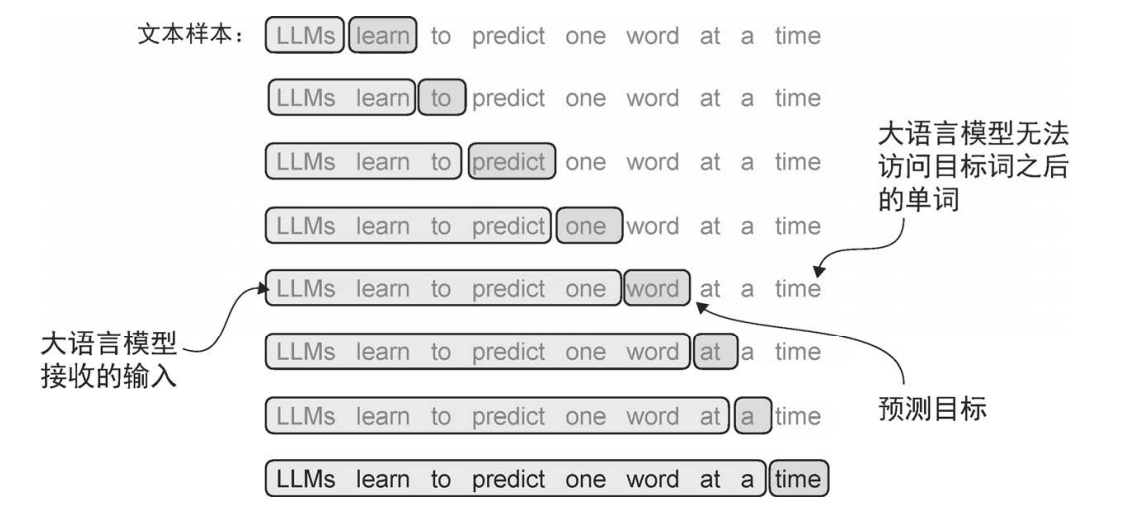

In [72]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
# 打开并读取原始文本文件

    raw_text = f.read()
    # 将整篇文本读入 raw_text 字符串

enc_text = tokenizer.encode(raw_text)
# 用 GPT-2 分词器把文本编码成 token ID 序列

print(len(enc_text))
# 输出 token ID 序列的长度

5145


对于每一个文本片段，我们都需要准备输入序列和对应的目标序列。因为模型的任务是预测下一个词（或下一个token），所以目标序列可以看作是把输入序列整体向右移动一位得到的，也就是输入的下一个位置就是要预测的目标。

In [73]:
enc_sample = enc_text[50:]
# 跳过开头一小段 token，用中间部分做演示样本，避免总是从文本开头开始

In [41]:
len(enc_sample)

5095

如果把预测过程按时间步一步一步展开来看，那么模型会像下面这样逐个位置进行预测，也就是在每一步根据已有的输入，预测下一个词（或下一个token）。

In [42]:
context_size = 4

x = enc_sample[:context_size]
y = enc_sample[1:context_size+1]

print(f"x:{x}")
print(f"       {y}")

x:[290, 4920, 2241, 287]
       [4920, 2241, 287, 257]


In [43]:
for i in range(1, context_size+1): 
 context = enc_sample[:i] 
 desired = enc_sample[i] 
 print(context, "---->", desired)

[290] ----> 4920
[290, 4920] ----> 2241
[290, 4920, 2241] ----> 287
[290, 4920, 2241, 287] ----> 257


In [44]:
for i in range(1, context_size+1): 
 context = enc_sample[:i] 
 desired = enc_sample[i] 
 print(tokenizer.decode(context), "---->", tokenizer.decode([desired]))

 and ---->  established
 and established ---->  himself
 and established himself ---->  in
 and established himself in ---->  a


我们现在先做一个简单的数据加载器，用来遍历输入数据集，并返回一对序列：输入序列，以及向右平移一位后的目标序列。

In [78]:
import torch

In [79]:
torch.__version__

'2.9.1'

In [80]:
# pip install torch==2.6.0

In [81]:
from torch.utils.data import Dataset, DataLoader

class GPTDatasetV1(Dataset):
# 用滑动窗口把一段长文本切成很多训练样本（输入序列与右移一位的目标序列）

    def __init__(self, txt, tokenizer, max_length, stride):
    # txt 是原始文本，max_length 是每个样本的序列长度，stride 是窗口每次滑动的步长

        self.input_ids = []
        # 保存每个样本的输入序列

        self.target_ids = []
        # 保存每个样本的目标序列（用于预测下一个 token）

        token_ids = tokenizer.encode(txt)
        # 把整段文本编码成 token ID 序列

        for i in range(0, len(token_ids) - max_length, stride):
        # 用滑动窗口从 token 序列中依次截取长度为 max_length 的片段

            input_chunk = token_ids[i:i + max_length]
            # 当前窗口的输入序列

            target_chunk = token_ids[i + 1: i + max_length + 1]
            # 目标序列比输入整体右移一位，用来做“预测下一个 token”

            self.input_ids.append(torch.tensor(input_chunk))
            # 把输入序列转成张量并保存

            self.target_ids.append(torch.tensor(target_chunk))
            # 把目标序列转成张量并保存

    def __len__(self):
    # 返回数据集中样本的数量

        return len(self.input_ids)
        # 样本数等于切出来的输入序列数量

    def __getitem__(self, idx):
    # 按索引返回一个样本（输入，目标）

        return self.input_ids[idx], self.target_ids[idx]
        # 返回第 idx 个输入序列和对应的目标序列

In [82]:
def create_dataloader_v1(txt, batch_size=4, max_length=256, stride=128,
                         shuffle=True, drop_last=True, num_workers=0):
# 创建一个 DataLoader，用于按批次产出输入序列和右移一位的目标序列

    tokenizer = tiktoken.get_encoding("gpt2")
    # 加载 GPT-2 的分词器，把文本编码成 token ID

    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)
    # 把长文本切成多个训练样本（滑动窗口+目标右移一位）

    dataloader = DataLoader(dataset, batch_size=batch_size,
                            shuffle=shuffle, drop_last=drop_last,
                            num_workers=num_workers)
    # 按 batch_size 组批，并可选择打乱与丢弃不完整的最后一个 batch

    return dataloader

我们来测试一下这个数据加载器，把批量大小设为1，并假设大语言模型的上下文长度是4，也就是每次输入4个token来预测下一个token。

In [83]:
with open("the-verdict.txt", "r", encoding="utf-8") as f: 
    raw_text = f.read()

In [84]:
dataloader = create_dataloader_v1( 
    raw_text, batch_size=1, max_length=4, stride=4, shuffle=False
)

data_iter = iter(dataloader) 
first_batch = next(data_iter) 
print(first_batch)

[tensor([[  40,  367, 2885, 1464]]), tensor([[ 367, 2885, 1464, 1807]])]


In [52]:
second_batch = next(data_iter)
print(second_batch)

[tensor([[1807, 3619,  402,  271]]), tensor([[ 3619,   402,   271, 10899]])]


下面展示一个例子，把stride设置为与上下文长度相同（这里是4），也就是每次窗口向前移动4个token来生成下一个样本。

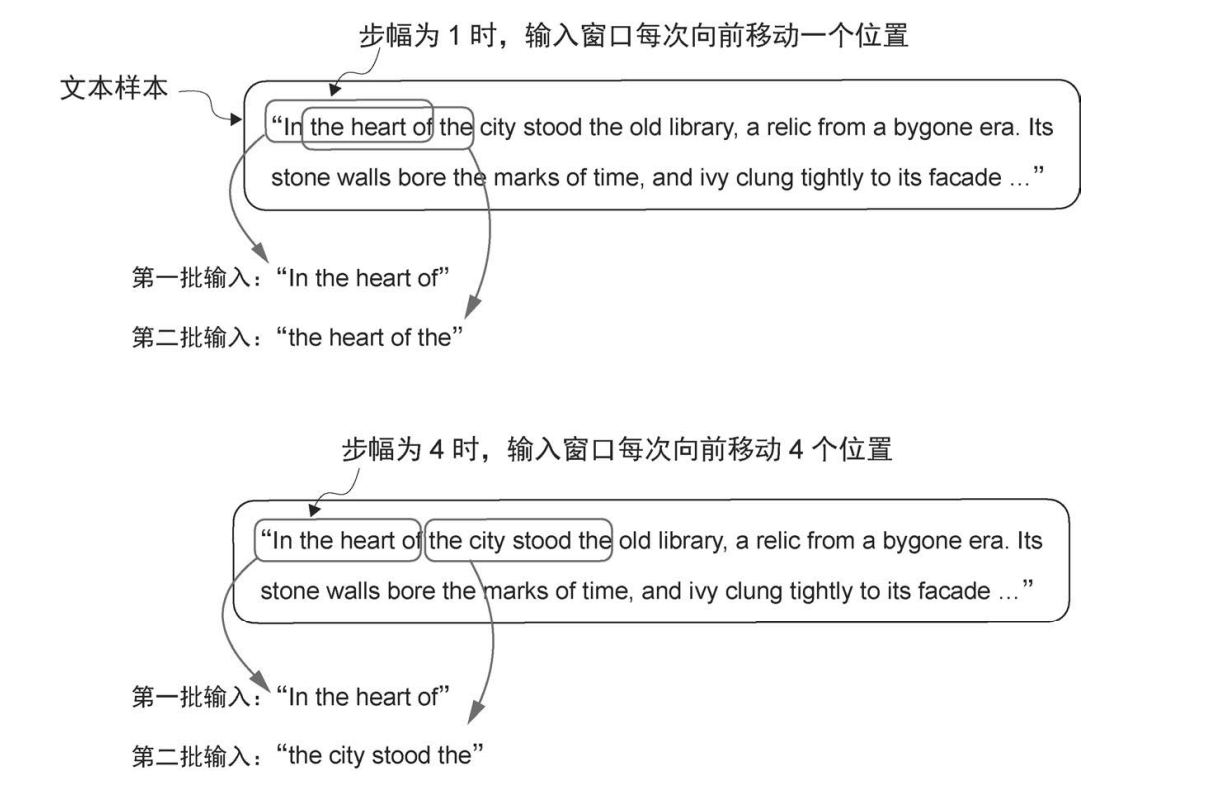

我们也可以把数据做成批量输出，也就是一次返回多个样本组成一个batch。需要注意的是，这里我们把stride设得更大一些，让不同样本之间尽量不要重叠，因为重叠太多会让训练数据变得过于相似，可能增加过拟合的风险。

In [85]:
dataloader = create_dataloader_v1(
    raw_text, batch_size=8, max_length=4, stride=4,
    shuffle=False
)
# 用上下文长度 4 和步长 4 生成数据，并一次取 8 条样本组成一个 batch

data_iter = iter(dataloader)
# 把 dataloader 变成迭代器，方便手动取出一个 batch

inputs, targets = next(data_iter)
# 取出第一个 batch 的输入序列和右移一位的目标序列

print("Inputs:\n", inputs)
print("\nTargets:\n", targets)

Inputs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Targets:
 tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])


### 2.7 创建词元嵌入

我们即将把token ID通过嵌入层转换成连续的向量表示。通常嵌入层是大语言模型本身的一部分，并且会在模型训练过程中一起被更新和学习，从而得到更适合任务的向量表示。

假设在完成分词并把token映射成编号之后，我们得到了四个输入样本，它们对应的输入ID分别是2、3、5和1。

In [54]:
inputs_ids = torch.tensor([2, 3, 5, 1])

为了便于理解，我们先把情况简化一下：假设词表里一共只有6个词（也就是token ID 的取值范围大致是0到5），并且我们希望把每个词的嵌入向量维度设为3，也就是说每个token最终会被映射成一个长度为3的连续数值向量。

In [86]:
vocab_size = 6
output_dim = 3

torch.manual_seed(123) # 固定一个随机种子

embedding_layer = torch.nn.Embedding(vocab_size,output_dim)

在这种设定下，嵌入层可以看作一张“查表用”的权重矩阵，它的形状会是6×3，也就是6行对应词表中的6个token，每一行是一个长度为3的嵌入向量。

In [87]:
print(embedding_layer.weight)

Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)


本质上相当于先把token ID变成one-hot向量，然后再通过一个全连接层的矩阵乘法得到对应的向量表示。

因为嵌入层与“one-hot加矩阵乘法”的结果是等价的，只是实现上更省计算、更省内存，所以它也可以看作神经网络中的一层参数化层，并且同样可以通过反向传播来优化更新这些嵌入向量。

为了把ID为3的token转换成一个3维向量，我们会在嵌入矩阵中取出第3行对应的那一行权重，这一行就是该token的3维嵌入表示。

In [57]:
embedding_layer(torch.tensor([3]))

tensor([[-0.4015,  0.9666, -1.1481]], grad_fn=<EmbeddingBackward0>)

In [58]:
embedding_layer(torch.tensor([2]))

tensor([[ 1.2753, -0.2010, -0.1606]], grad_fn=<EmbeddingBackward0>)

需要注意的是，上面取到的其实是嵌入层权重矩阵中的第4行，因为索引从0开始计数，ID为3对应的就是第0、1、2、3里的第4个位置。要把前面那四个输入ID都转换成向量表示，我们就对这四个ID一次性做嵌入查表，得到四个对应的嵌入向量。

### 2.8 编码单词位置信息

嵌入层把ID映射成向量时，只看“这个ID是什么”，不会看它在输入序列里的位置在哪里，所以同一个token ID无论出现在序列的哪个位置，得到的嵌入向量都是一样的。

**位置嵌入（positional embedding）** 会与token的嵌入向量结合在一起，形成大语言模型最终使用的 **输入嵌入（input embeddings）**，这样模型不仅知道“是什么词”，也能知道“出现在序列的哪个位置”。

In [59]:
embedding_layer(inputs_ids)

tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)

GPT-2使用的BPE分词器词表大小是50,257，也就是一共有50,257个不同的token ID。假设我们希望把每个token编码成一个256维的向量表示，那么嵌入层就会为每个token学习一个长度为256的向量。

换句话说，这个嵌入层可以看作一张“查表矩阵”，它的形状会是50,257×256，每一行对应一个token ID的256维向量。

In [65]:
vocab_size = 50257
output_dim = 256

token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

如果我们从数据加载器里取出一个batch，然后用嵌入层把其中的每个token ID都转换成一个256维的向量，那么这个batch里的所有token就会被同时“查表”成连续向量。

比如当批量大小是8，并且每条样本里有4个token时，嵌入后的结果就是一个形状为8×4×256的三维张量，其中第一个维度8表示一共有8条样本，第二个维度4表示每条样本的序列长度是4个token，第三个维度256表示每个token对应的嵌入向量长度是256。

In [88]:
max_length = 4
# 设置上下文长度，每条样本包含 4 个 token

dataloader = create_dataloader_v1(
    raw_text, batch_size=8, max_length=max_length,
    stride=max_length, shuffle=False
)
# 用步长等于上下文长度生成不重叠样本，并按 batch_size=8 组成一个 batch

data_iter = iter(dataloader)
# 创建迭代器，方便手动取出一个 batch

inputs, targets = next(data_iter)
# 取出第一个 batch 的输入序列和右移一位的目标序列


In [89]:
print("Token IDs:\n", inputs) 
print("\nInputs shape:\n", inputs.shape)

Token IDs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Inputs shape:
 torch.Size([8, 4])


In [68]:
token_embeddings = token_embedding_layer(inputs)
# 把输入的 token ID 通过嵌入层转换成向量表示

token_embeddings.shape

torch.Size([8, 4, 256])

In [69]:
token_embeddings[0,0]

tensor([-7.5886e-01, -2.9304e-03,  4.6033e-01, -1.2624e+00,  2.2945e-02,
         8.7158e-01, -4.0860e-01,  3.0992e+00, -3.3686e-01,  1.6070e+00,
        -5.9332e-01, -1.6217e+00, -9.8342e-01, -2.0415e-01, -1.9045e+00,
        -3.5749e-01,  1.9803e+00, -1.2905e+00,  1.7485e+00,  8.1073e-01,
        -4.6945e-01, -1.3970e+00, -5.9203e-01, -4.0787e-01, -8.8608e-01,
         7.4233e-02,  1.0778e+00, -4.8303e-01,  1.7835e-01, -1.8202e-02,
         1.2433e+00,  1.2383e+00, -1.0246e+00,  1.0360e+00, -7.9023e-02,
         6.9433e-01,  9.0482e-01, -5.9876e-01, -2.0244e-01, -2.3003e-01,
        -1.8838e+00,  7.8860e-01, -1.5495e-01, -2.6969e-01,  8.0673e-02,
         1.8647e+00,  1.9773e-01,  3.6746e-01, -6.1770e-01, -2.2325e-01,
         5.0203e-01, -1.0905e+00,  1.9047e+00,  1.7961e+00,  3.6618e-01,
        -1.1885e+00,  1.9014e+00, -4.4768e-01, -9.0395e-01,  4.8624e-01,
         1.2517e+00,  1.0142e+00,  2.0751e-01,  1.0113e+00,  1.0095e+00,
        -9.3878e-01,  1.3766e-01,  8.3255e-01,  1.0

GPT-2使用的是 **绝对位置嵌入（absolute position embedding）**，也就是说它会为序列中的每一个位置分配一个固定的“位置编号”，再把这个位置编号通过一个嵌入层映射成向量。因为位置嵌入和token嵌入在形式上很像，都是“用一个ID去查一行向量”，所以实现上通常就是再创建一个新的嵌入层，输入是位置ID，输出是与token嵌入同维度的向量，后面再把两者结合起来作为模型的输入表示。

In [90]:
context_length = max_length
# 位置编号的范围等于序列长度（0 到 max_length-1）

pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)
# 创建位置嵌入层：把每个位置 ID 映射成 output_dim 维向量

In [71]:
torch.arange(max_length)

tensor([0, 1, 2, 3])

In [92]:
pos_embedding_layer.weight
# 位置嵌入层的权重矩阵

Parameter containing:
tensor([[-0.4709, -0.4269, -0.0283],
        [ 1.4220, -0.3886, -0.8903],
        [-0.9601, -0.4087,  1.0764],
        [-0.4015, -0.7291, -0.1218]], requires_grad=True)

In [93]:
pos_embedding_layer(torch.arange(max_length))
# 生成位置 ID（0 到 max_length-1），并查表得到对应的位置嵌入向量

tensor([[-0.4709, -0.4269, -0.0283],
        [ 1.4220, -0.3886, -0.8903],
        [-0.9601, -0.4087,  1.0764],
        [-0.4015, -0.7291, -0.1218]], grad_fn=<EmbeddingBackward0>)

In [94]:
pos_embeddings = pos_embedding_layer(torch.arange(context_length)) 
# 为序列中每个位置生成对应的位置嵌入向量

print(pos_embeddings.shape)

torch.Size([4, 3])


为了得到大语言模型实际使用的输入嵌入，我们只需要把token的嵌入向量和对应位置的位置嵌入向量相加即可。这样相加后的向量同时包含了“这个token的语义信息”和“它在序列中的位置信息”，模型就能在后续的注意力计算中利用顺序关系来理解文本。

In [75]:
token_embeddings + pos_embeddings

tensor([[[ 0.3767, -1.2013,  1.6755,  ...,  0.1748,  0.0702, -2.5195],
         [-1.2291, -1.3310,  1.4863,  ..., -0.6984, -0.2037, -0.3383],
         [ 1.2876, -0.6571,  0.4646,  ..., -0.3761,  0.2941, -0.4188],
         [ 2.2767, -0.0425, -2.3572,  ..., -2.3314, -0.2127,  1.9574]],

        [[ 2.7240, -2.4255,  0.5727,  ..., -0.4438,  0.2485,  0.5598],
         [-0.6352, -1.1958,  0.3772,  ..., -0.4077,  0.1490, -1.2530],
         [ 2.1384, -0.1643, -0.0246,  ...,  0.9049,  0.4139, -0.3490],
         [ 2.0495,  1.5002,  1.7855,  ..., -1.0115,  0.2011,  0.0664]],

        [[ 2.0021, -2.3743,  2.9815,  ..., -0.2482,  0.9656, -2.0332],
         [-1.5463, -0.1748,  1.9052,  ..., -1.0238, -1.5514, -0.7158],
         [ 0.4419,  2.1966, -0.0338,  ..., -0.5205,  1.5683,  0.7743],
         [ 1.8208, -0.8542,  0.3448,  ...,  0.4018, -0.5443, -1.3357]],

        ...,

        [[ 2.3657, -2.4226,  1.0158,  ...,  0.7209,  0.1543, -1.4738],
         [-1.2490,  0.3912,  2.1181,  ...,  1.1095, -2.33

In [76]:
input_embeddings = token_embeddings + pos_embeddings 
print(input_embeddings.shape)

torch.Size([8, 4, 256])


在输入处理流程的最开始，原始文本会先被切分成一个个独立的token。完成切分之后，这些token会根据预先定义好的词表被映射成对应的数字编号，也就是token ID。

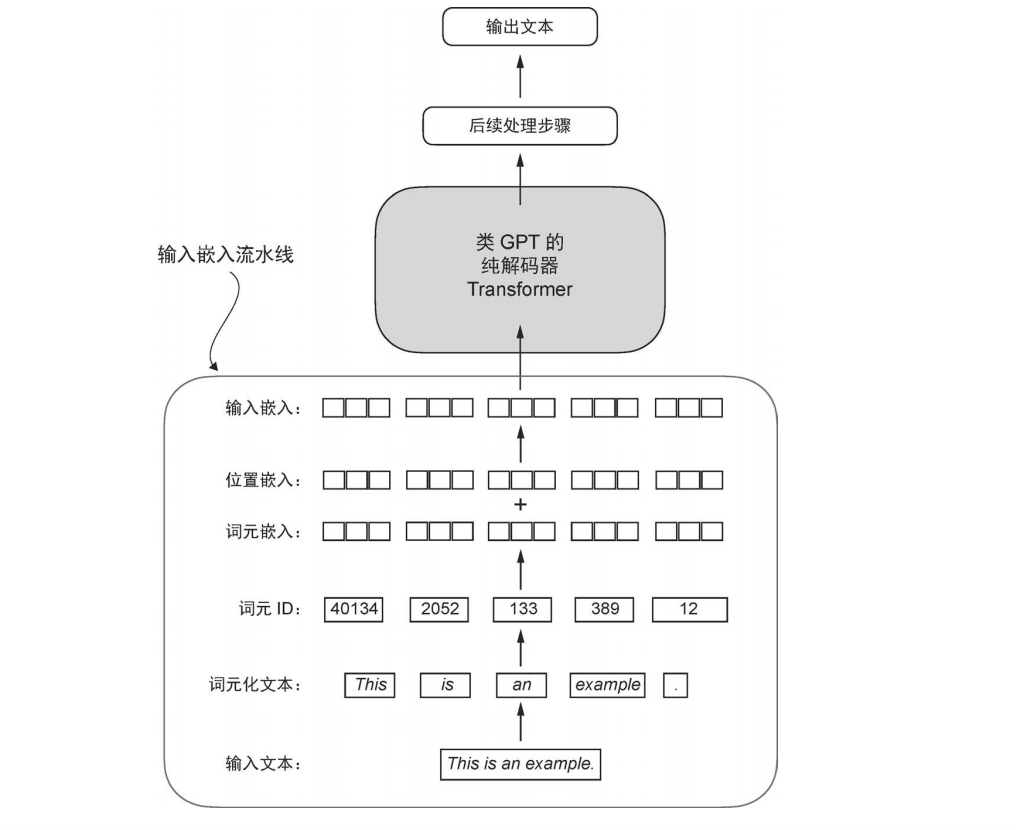